<a href="https://colab.research.google.com/github/AlesioRios/Laboratorio-de-Datos-II/blob/main/Lab_de_Datos_II_TP4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# EDA — Fashion MNIST (TP4A)
<!-- EDA_FASHION_MNIST -->

**Modo A:** EDA previo al preprocesamiento. Se trabaja sobre los datos crudos (`X_train`, `y_train`, `X_test`, `y_test`) sin modificarlos: cuando un análisis necesita escalar o aplanar, lo hace sobre copias con prefijo `eda_`.

Cada análisis responde una pregunta que hay que contestar en los ejercicios del TP:

| Ejercicio | Qué necesita saber del dato |
|---|---|
| 1.1 Random Forest + matriz de confusión | ¿Qué clases se parecen entre sí? ¿Están balanceadas? |
| 1.2 RF binario + ROC/AUC | ¿Qué par de clases conviene elegir (fácil vs. difícil)? |
| 2 Optuna sobre RF | ¿Cuántas features aportan información? ¿Cuánto cuesta cada trial? |
| 3 MLP con poda | ¿Qué escala necesitan los píxeles? ¿Hay diferencias train/test? |

**Heurísticas declaradas:** n = 70.000 > 50.000 → los gráficos de dispersión y t-SNE/UMAP usan una muestra estratificada con `random_state=42`. Variables > 8 (784 píxeles) → sin pairplot: se usa PCA. Ninguna etiqueta es un identificador (10 clases).

## 0. Imports y funciones auxiliares
`estilizar` y `mostrar_lado_a_lado` son las mismas definidas en el notebook del TP1 (mismo nombre y firma).

In [2]:
# !pip install umap-learn   # descomentar si UMAP no esta instalado (Colab)
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import umap

SEMILLA = 42

NOMBRES_CLASES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                  'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Misma clase, mismo color en todos los graficos del analisis
PALETA_CLASES = sns.color_palette('tab10', 10)


def estilizar(df, cmap='Blues', precision=2):
  #Codifica una tabla con color en vez de imprimirla como texto plano (heatmap-style, por columna).
  #Ademas de background_gradient, se agregan estilos de tabla explicitos: al extraer el
  #HTML con .to_html() para mostrarlo dentro de un <div> propio (mostrar_lado_a_lado),
  #se pierde el CSS por default que Colab/Jupyter le pone a un DataFrame (padding, bordes,
  #tipografia) - sin esto se ve mas apretado/plano que una tabla mostrada normalmente.
  estilos_tabla = [
      {'selector': 'th', 'props': [('padding', '6px 12px'), ('text-align', 'center'), ('border', '1px solid #d0d7de'), ('background-color', '#f6f8fa')]},
      {'selector': 'td', 'props': [('padding', '6px 12px'), ('text-align', 'center'), ('border', '1px solid #d0d7de')]},
      {'selector': ''  , 'props': [('border-collapse', 'collapse'), ('font-size', '13px')]},
  ]
  return (
      df.style
      .background_gradient(cmap=cmap, axis=0)
      .format(precision=precision)
      .set_table_styles(estilos_tabla)
  )

def mostrar_lado_a_lado(tablas, cmap='Blues', precision=2):
  #Muestra varias tablas en una fila horizontal (en vez de apiladas) para que entren juntas en pantalla.
  #Cada tabla queda dentro de una tarjeta con borde propio, con mas separacion entre ellas
  #y entre el titulo y la tabla, para que se vea prolijo en vez de amontonado.
  bloques = []
  for titulo, df in tablas:
    bloques.append(
        "<div style='margin:0 32px 20px 0; padding:12px 14px; "
        "border:1px solid #d0d7de; border-radius:10px;'>"
        f"<div style='font-weight:600; margin-bottom:8px;'>{titulo}</div>"
        f"{estilizar(df, cmap=cmap, precision=precision).to_html()}</div>"
    )
  display(HTML("<div style='display:flex; flex-wrap:wrap;'>" + ''.join(bloques) + "</div>"))


def mostrar_tabla_texto(df):
    # Tabla de texto (sin gradiente): estilizar() aplica un gradiente numerico por columna
    # y aqui las celdas son frases, no numeros.
    estilos = [
        {'selector': 'th', 'props': [('padding', '6px 12px'), ('text-align', 'left'), ('border', '1px solid #d0d7de'), ('background-color', '#f6f8fa')]},
        {'selector': 'td', 'props': [('padding', '6px 12px'), ('text-align', 'left'), ('border', '1px solid #d0d7de')]},
        {'selector': '', 'props': [('border-collapse', 'collapse'), ('font-size', '13px')]},
    ]
    display(df.style.hide(axis='index').set_table_styles(estilos))


def muestra_estratificada(y, n_por_clase, semilla=SEMILLA):
    # Muestra con la misma cantidad por clase: con clases balanceadas es equivalente
    # a estratificar por proporcion, y garantiza que ninguna clase quede sub-representada.
    rng = np.random.default_rng(semilla)
    indices = [rng.choice(np.where(y == c)[0], n_por_clase, replace=False) for c in np.unique(y)]
    return np.sort(np.concatenate(indices))


def grilla_imagenes(imagenes, titulos, filas, columnas, titulo_general, cmap='gray',
                    vmin=None, vmax=None, colorbar_label=None):
    # Una sola figura para todas las imagenes; vmin/vmax compartidos para que los
    # colores sean comparables entre paneles (si no, cada panel se auto-escala).
    fig, ejes = plt.subplots(filas, columnas, figsize=(columnas * 2.6, filas * 2.9))
    for ax, img, tit in zip(ejes.ravel(), imagenes, titulos):
        im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(tit, fontsize=10)
        ax.axis('off')
    fig.suptitle(titulo_general, fontsize=13)
    if colorbar_label is not None:
        fig.colorbar(im, ax=ejes.ravel().tolist(), shrink=0.7, label=colorbar_label)
    else:
        plt.tight_layout()
    plt.show()


def heatmap_triangular(matriz, titulo, ax, cmap, fmt='.2f', centro=None):
    # Matriz simetrica: solo triangulo inferior y sin diagonal (la diagonal es
    # constante y no informa). Al quitar la diagonal, la primera fila y la ultima
    # columna quedan vacias, asi que se recortan para no dejar un panel en blanco.
    recorte = matriz[1:, :-1]
    mascara = np.triu(np.ones_like(recorte, dtype=bool), k=1)
    sns.heatmap(recorte, mask=mascara, annot=True, fmt=fmt, cmap=cmap, center=centro,
                xticklabels=NOMBRES_CLASES[:-1], yticklabels=NOMBRES_CLASES[1:],
                linewidths=0.5, cbar_kws={'shrink': 0.7}, ax=ax)
    ax.set_title(titulo)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)


def dispersion_por_clase(Z, y, ax, titulo):
    # Un scatter por proyeccion, coloreado por clase con la paleta fija del analisis.
    for c in range(10):
        m = y == c
        ax.scatter(Z[m, 0], Z[m, 1], s=4, alpha=0.6, color=PALETA_CLASES[c], label=NOMBRES_CLASES[c])
    ax.set_title(titulo)
    ax.set_xticks([])
    ax.set_yticks([])

## 1. Estructura y calidad del dato
**Pregunta:** ¿el dato viene limpio o hay algo (duplicados, etiquetas contradictorias, imágenes vacías, solapamiento train/test) que afecte el modelado?

**Por qué así:** una tabla de chequeos es lo que corresponde a un dataset de imágenes donde no hay columnas que perfilar. Se usa un hash por imagen para detectar duplicados exactos sin comparar 60.000² pares.

In [3]:
def hash_imagenes(X):
    # Hash del contenido de cada imagen: dos imagenes identicas dan el mismo hash.
    return np.array([hashlib.md5(img.tobytes()).hexdigest() for img in X])


h_train = hash_imagenes(X_train)
h_test = hash_imagenes(X_test)

por_hash = pd.DataFrame({'hash': h_train, 'clase': y_train}).groupby('hash')['clase'].agg(['size', 'nunique'])
plano_train = X_train.reshape(len(X_train), -1)

chequeos = pd.DataFrame({
    'Chequeo': ['Forma de X_train', 'Forma de X_test', 'Tipo de dato', 'Rango de valores',
                'Nulos (NaN) en X_train',
                'Imagenes duplicadas exactas en train (filas extra)',
                'Hashes con etiquetas contradictorias en train',
                'Imagenes de test que tambien estan en train',
                'Imagenes completamente vacias (todo 0) en train',
                'Pixeles con varianza cero en train (de 784)'],
    'Valor': [str(X_train.shape), str(X_test.shape), str(X_train.dtype),
              f'[{X_train.min()}, {X_train.max()}]',
              int(np.isnan(X_train.astype(float)).sum()),
              int((por_hash['size'] - 1).sum()),
              int((por_hash['nunique'] > 1).sum()),
              int(np.isin(h_test, h_train).sum()),
              int((plano_train.max(axis=1) == 0).sum()),
              int((plano_train.std(axis=0) == 0).sum())],
})
mostrar_tabla_texto(chequeos.astype({'Valor': str}))

Chequeo,Valor
Forma de X_train,"(60000, 28, 28)"
Forma de X_test,"(10000, 28, 28)"
Tipo de dato,uint8
Rango de valores,"[0, 255]"
Nulos (NaN) en X_train,0
Imagenes duplicadas exactas en train (filas extra),0
Hashes con etiquetas contradictorias en train,0
Imagenes de test que tambien estan en train,0
Imagenes completamente vacias (todo 0) en train,0
Pixeles con varianza cero en train (de 784),0


### Conclusiones — Estructura y calidad

- ¿Hay duplicados o etiquetas contradictorias? ¿Cambia algo para el entrenamiento?
- Si hay imágenes de test que también están en train, ¿qué implica para interpretar el accuracy del test?
- Los píxeles con varianza cero, ¿aportan algo a un Random Forest? ¿Y a un MLP?

<!-- Completar -->

## 2. Un ejemplo por clase
**Pregunta:** ¿a qué prenda corresponde cada etiqueta y cómo se ve? (la consigna lo pide antes de empezar).

**Por qué así:** una grilla de 2×5 con la primera imagen de cada clase, todas con la misma escala de grises (`vmin=0, vmax=255`).

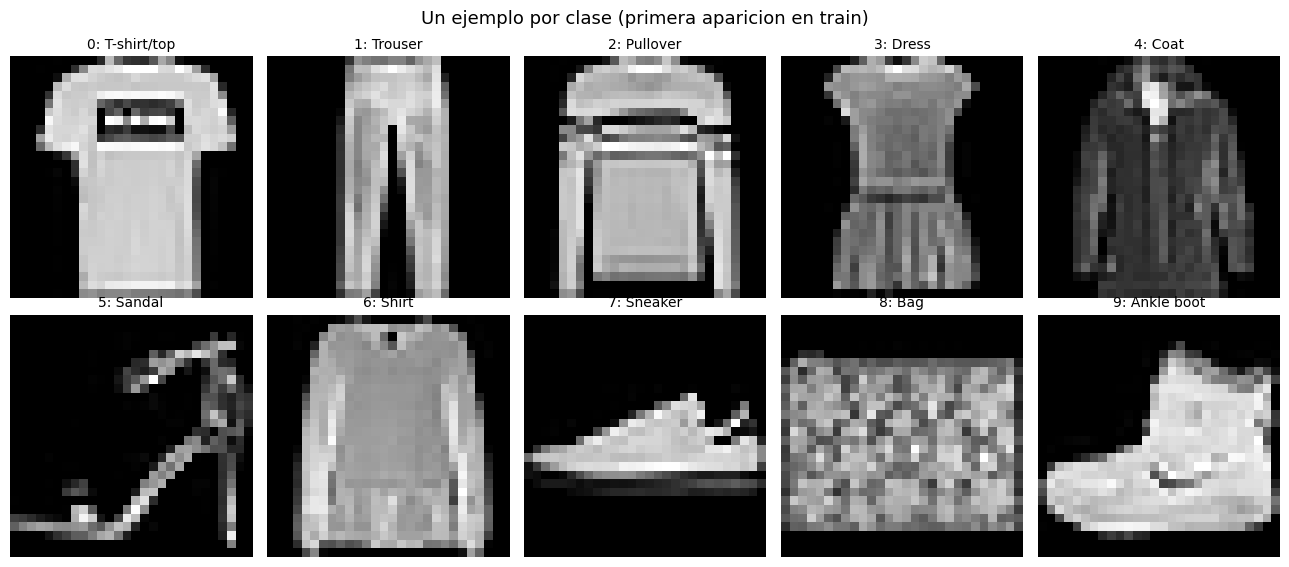

In [4]:
primeras = [np.where(y_train == c)[0][0] for c in range(10)]
grilla_imagenes([X_train[i] for i in primeras],
                [f'{c}: {NOMBRES_CLASES[c]}' for c in range(10)],
                2, 5, 'Un ejemplo por clase (primera aparicion en train)', vmin=0, vmax=255)

### Conclusiones — Ejemplos por clase

- ¿Qué pares de prendas se parecen incluso a simple vista?
- ¿La orientación, el centrado y el tamaño son consistentes entre clases?

<!-- Completar -->

## 3. Balance de clases
**Pregunta:** ¿las clases están balanceadas en train y en test? Define si accuracy es una métrica confiable para Optuna (Ejercicio 2) y para la poda (Ejercicio 3).

**Por qué así:** barras horizontales con línea base en cero; una tabla de conteos al lado con la proporción de cada clase.

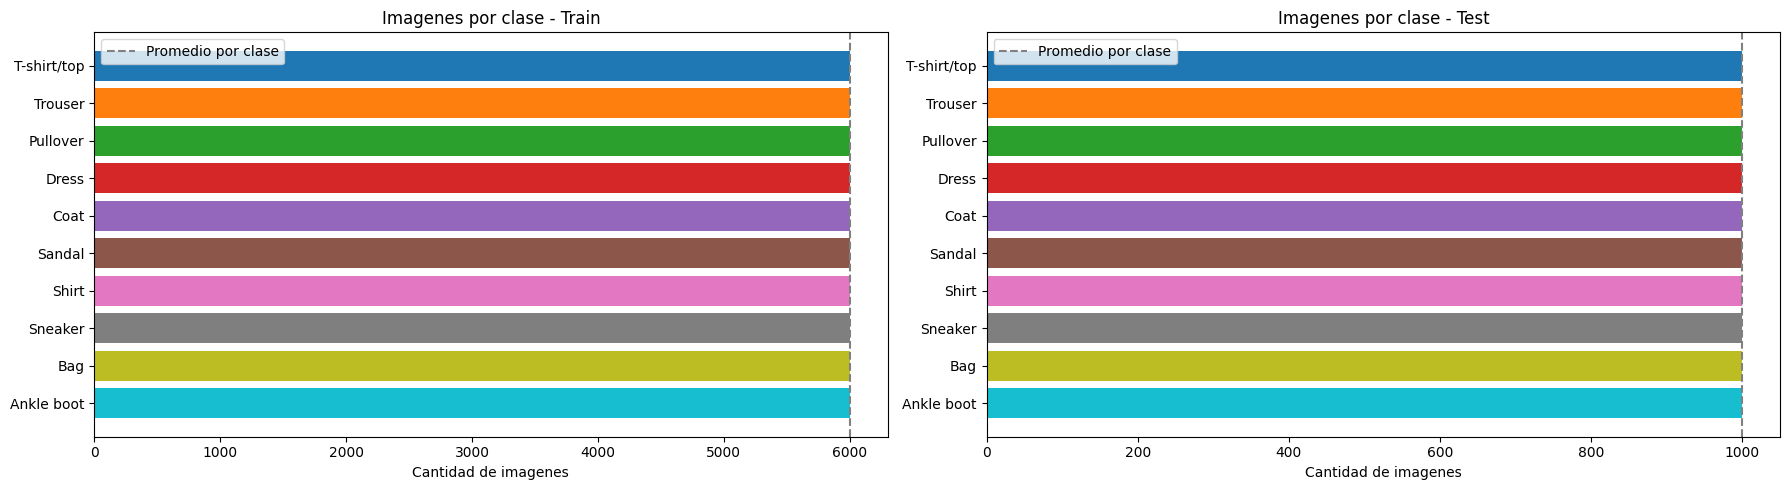

,Train,% Train,Test,% Test
Clase,,,,
T-shirt/top,6000,10.0,1000,10.0
Trouser,6000,10.0,1000,10.0
Pullover,6000,10.0,1000,10.0
Dress,6000,10.0,1000,10.0
Coat,6000,10.0,1000,10.0
Sandal,6000,10.0,1000,10.0
Shirt,6000,10.0,1000,10.0
Sneaker,6000,10.0,1000,10.0
Bag,6000,10.0,1000,10.0


Accuracy de un clasificador que adivina al azar: 10.00%


In [5]:
cuentas_train = pd.Series(y_train).value_counts().sort_index()
cuentas_test = pd.Series(y_test).value_counts().sort_index()
tabla_balance = pd.DataFrame({
    'Clase': NOMBRES_CLASES,
    'Train': cuentas_train.values,
    '% Train': cuentas_train.values / len(y_train) * 100,
    'Test': cuentas_test.values,
    '% Test': cuentas_test.values / len(y_test) * 100,
}).set_index('Clase')

fig, ejes = plt.subplots(1, 2, figsize=(18, 5), sharex=False)
for ax, cuentas, nombre in zip(ejes, [cuentas_train, cuentas_test], ['Train', 'Test']):
    ax.barh(NOMBRES_CLASES, cuentas.values, color=PALETA_CLASES)
    ax.axvline(cuentas.values.mean(), color='gray', linestyle='--', label='Promedio por clase')
    ax.set_title(f'Imagenes por clase - {nombre}')
    ax.set_xlabel('Cantidad de imagenes')
    ax.invert_yaxis()
    ax.legend()
plt.tight_layout()
plt.show()

mostrar_lado_a_lado([('Conteo y proporcion por clase', tabla_balance)], cmap='Blues', precision=1)
print(f'Accuracy de un clasificador que adivina al azar: {1 / 10:.2%}')

### Conclusiones — Balance de clases
Como podemos ver las clases estan completamente balanceadas, por lo que en este caso es  válido aplicar el accuraccy.La exactitud (accuracy) se vuelve engañosa principalmente cuando hay desbalance entre clases ya que si predice solo la clase mayoritaria el accuracy solo infla el puntaje sin realmente ser capaz de aprender. Al estar las clases completamente balanceadas la tasa de aciertos refleja de manera fiel el rendimiento general del modelo. Optuna puede usar accuracy como función objetivo a maximizar sin riesgo de caer en el sesgo de clase mayoritaria.



## 4. Distribución de intensidades de píxel
**Pregunta:** ¿qué rango y forma tienen los valores? Justifica dividir por 255 y anticipa si Random Forest y MLP necesitan esa normalización.

**Por qué así:** el histograma de todos los píxeles está dominado por el 0 (fondo negro), por eso se muestra aparte el % de ceros por clase y la intensidad media por imagen. Los píxeles distintos de cero se grafican sin el 0 para que se vea su forma.

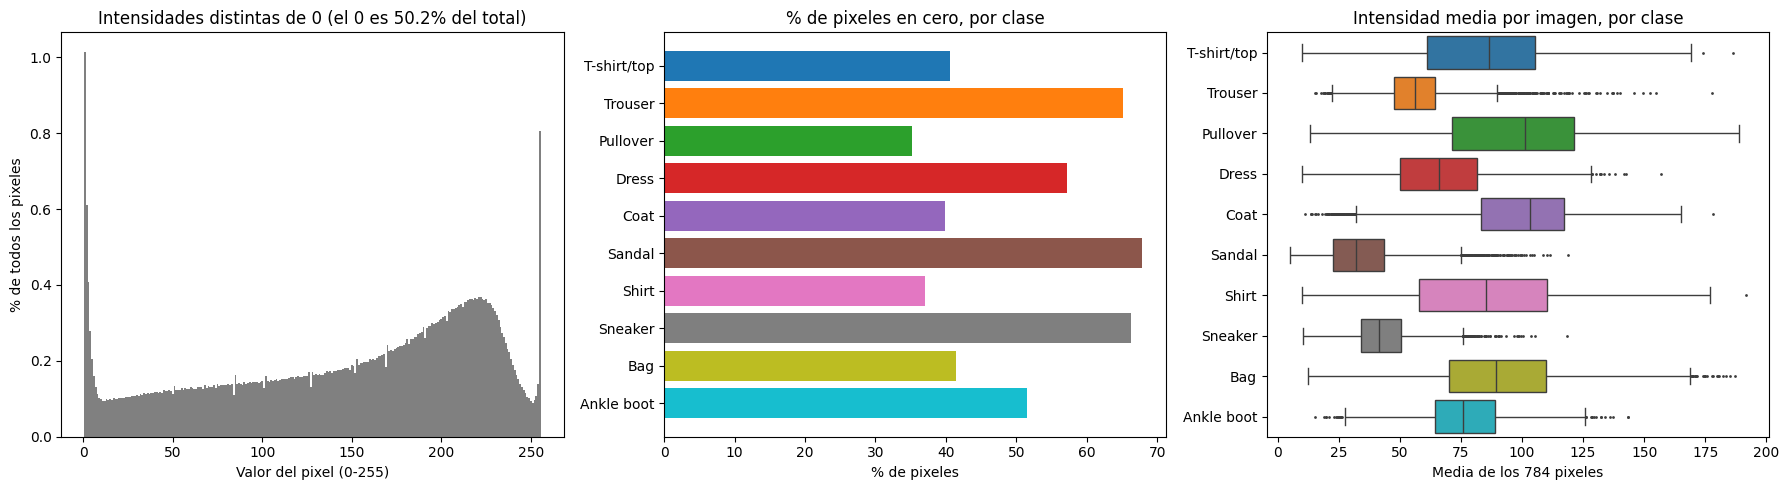

,Media,Desvio,Minimo,Maximo
Clase,,,,
T-shirt/top,83.0,28.9,9.8,186.3
Trouser,56.8,14.5,15.1,177.8
Pullover,96.1,32.7,13.2,188.7
Dress,66.0,21.4,9.8,156.9
Coat,98.3,26.4,11.1,178.1
Sandal,34.9,15.8,4.9,118.8
Shirt,84.6,33.1,10.0,191.8
Sneaker,42.8,12.8,10.4,118.3
Bag,90.2,28.8,12.2,187.2


In [6]:
conteo_valores = np.bincount(X_train.ravel(), minlength=256)
pct_ceros_clase = [(X_train[y_train == c] == 0).mean() * 100 for c in range(10)]
media_por_imagen = X_train.reshape(len(X_train), -1).mean(axis=1)

fig, ejes = plt.subplots(1, 3, figsize=(18, 5))

ejes[0].bar(np.arange(1, 256), conteo_valores[1:] / conteo_valores.sum() * 100, color='gray', width=1.0)
ejes[0].set_title(f'Intensidades distintas de 0 (el 0 es {conteo_valores[0] / conteo_valores.sum():.1%} del total)')
ejes[0].set_xlabel('Valor del pixel (0-255)')
ejes[0].set_ylabel('% de todos los pixeles')

ejes[1].barh(NOMBRES_CLASES, pct_ceros_clase, color=PALETA_CLASES)
ejes[1].set_title('% de pixeles en cero, por clase')
ejes[1].set_xlabel('% de pixeles')
ejes[1].invert_yaxis()

nombres_train = [NOMBRES_CLASES[c] for c in y_train]
sns.boxplot(x=media_por_imagen, y=nombres_train, hue=nombres_train, order=NOMBRES_CLASES,
            hue_order=NOMBRES_CLASES, palette=dict(zip(NOMBRES_CLASES, PALETA_CLASES)),
            orient='h', legend=False, ax=ejes[2], fliersize=1)
ejes[2].set_title('Intensidad media por imagen, por clase')
ejes[2].set_xlabel('Media de los 784 pixeles')
ejes[2].set_ylabel('')
plt.tight_layout()
plt.show()

resumen_int = pd.DataFrame({'Clase': [NOMBRES_CLASES[c] for c in y_train], 'media': media_por_imagen}) \
    .groupby('Clase')['media'].agg(['mean', 'std', 'min', 'max']).reindex(NOMBRES_CLASES)
resumen_int.columns = ['Media', 'Desvio', 'Minimo', 'Maximo']
mostrar_lado_a_lado([('Intensidad media por imagen (escala 0-255)', resumen_int)], cmap='Blues', precision=1)

### Conclusiones — Intensidades de píxel

- ¿Qué proporción de los datos es fondo (0)? ¿Qué implica para la dimensionalidad efectiva?
- ¿Qué clases tienen imágenes más 'llenas' y cuáles más 'vacías'? ¿Eso ya las separa?
- ¿Random Forest cambia si se divide por 255? ¿Y un MLPClassifier?

<!-- Completar -->

## 5. Imagen media y desvío por píxel, por clase
**Pregunta:** ¿qué zonas de la imagen identifican a cada clase y cuáles varían más dentro de una misma clase? Anticipa qué clases va a confundir el modelo en el Ejercicio 1.1.

**Por qué así:** la imagen media de cada clase resume su 'forma típica'; el desvío por píxel muestra dónde es más heterogénea. Ambas usan escala compartida para poder comparar entre clases.

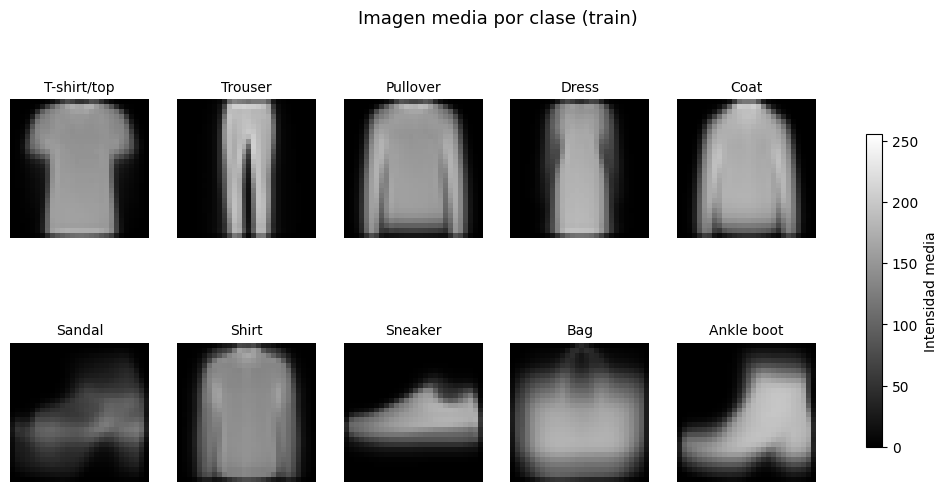

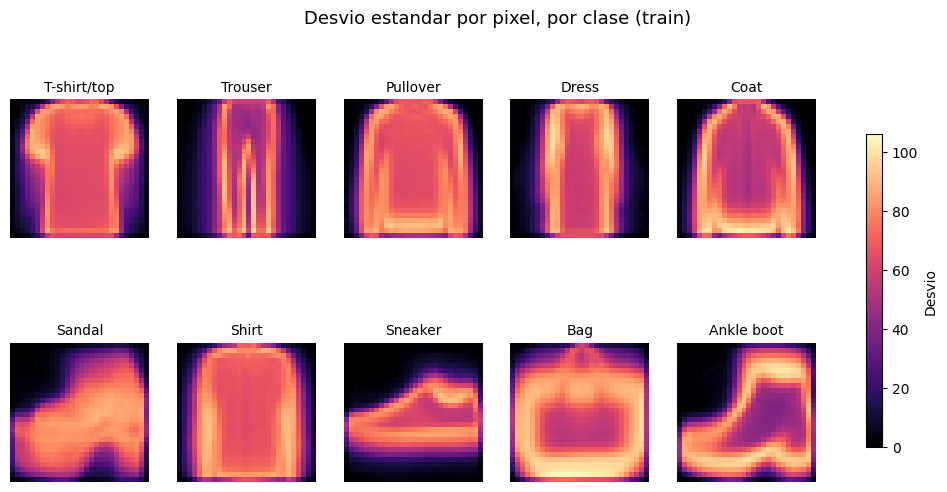

,Pixeles por debajo (de 784)
Umbral de desvio global (0-255),
0,0
5,20
20,73
50,167


In [7]:
medias = np.stack([X_train[y_train == c].mean(axis=0) for c in range(10)])
desvios = np.stack([X_train[y_train == c].std(axis=0) for c in range(10)])

grilla_imagenes(medias, NOMBRES_CLASES, 2, 5, 'Imagen media por clase (train)',
                cmap='gray', vmin=0, vmax=255, colorbar_label='Intensidad media')
grilla_imagenes(desvios, NOMBRES_CLASES, 2, 5, 'Desvio estandar por pixel, por clase (train)',
                cmap='magma', vmin=0, vmax=desvios.max(), colorbar_label='Desvio')

desvio_global = X_train.std(axis=0)
bajos = pd.DataFrame({
    'Umbral de desvio global (0-255)': [0, 5, 20, 50],
    'Pixeles por debajo (de 784)': [int((desvio_global <= u).sum()) for u in [0, 5, 20, 50]],
}).set_index('Umbral de desvio global (0-255)')
mostrar_lado_a_lado([('Pixeles casi constantes', bajos)], cmap='Blues', precision=0)

### Conclusiones — Imagen media y desvío

- ¿Qué clases tienen imágenes medias muy parecidas? ¿Coinciden con las que se ven parecidas en la sección 2?
- ¿Qué zona de la imagen concentra más variabilidad dentro de cada clase?
- ¿Cuántos píxeles casi no varían? ¿Por qué no es un problema para un Random Forest?

<!-- Completar -->

## 6. PCA: dimensionalidad efectiva
**Pregunta:** ¿cuántas de las 784 dimensiones contienen información? ¿Se separan las clases en 2D?

**Por qué así:** el scree plot con varianza acumulada responde cuántos componentes hacen falta; la proyección 2D coloreada por clase da una primera idea de separabilidad; los componentes vistos como imágenes muestran qué patrón captura cada uno.

**Escalado:** se divide por 255 (misma normalización que pide la guía) y PCA centra los datos. No se usa `StandardScaler` porque todos los píxeles comparten unidad y escala, y estandarizar inflaría el ruido de los bordes casi constantes. Se ajusta solo con train.

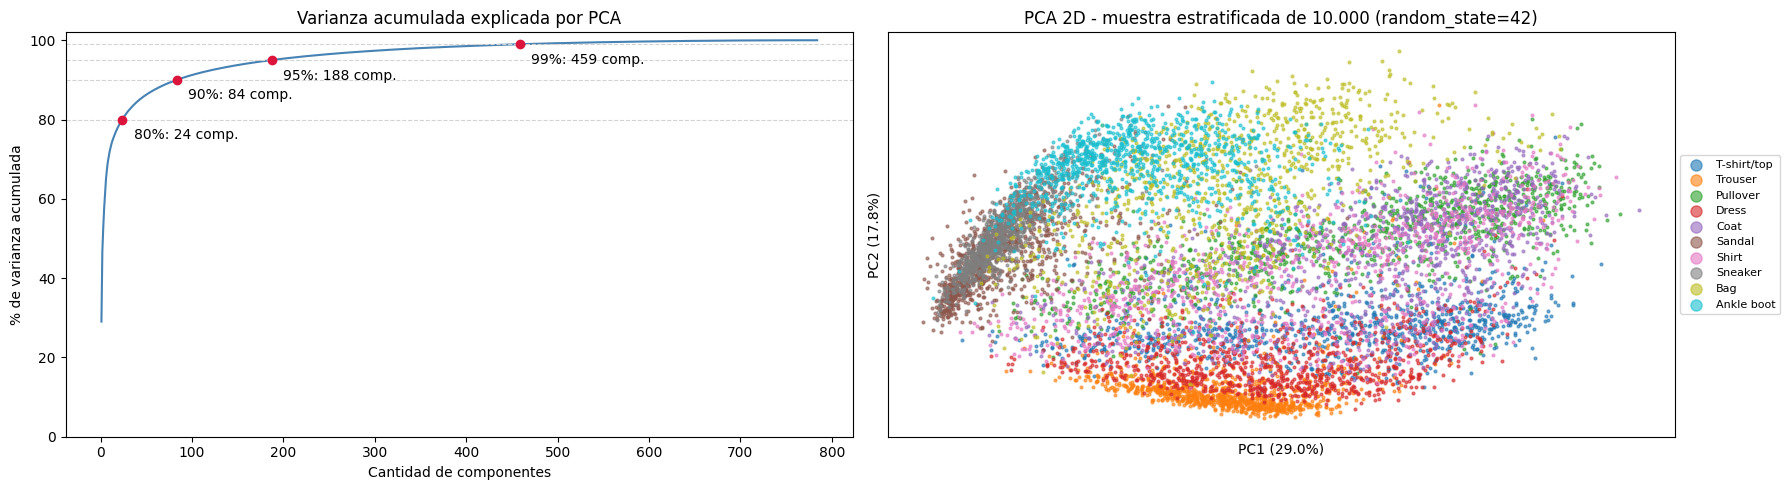

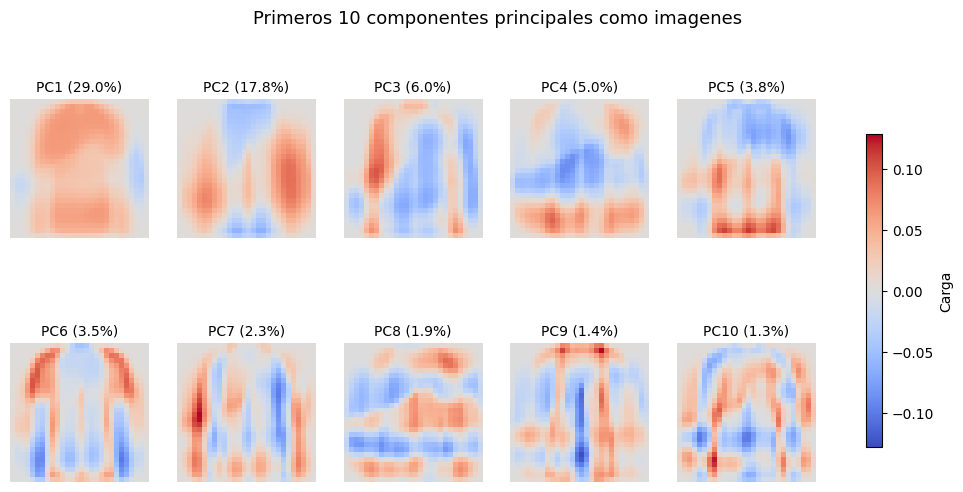

In [8]:
eda_X = X_train.reshape(len(X_train), -1).astype(np.float32) / 255.0
eda_X_test = X_test.reshape(len(X_test), -1).astype(np.float32) / 255.0

pca = PCA(random_state=SEMILLA).fit(eda_X)
var_acum = np.cumsum(pca.explained_variance_ratio_)
comp_para = {p: int(np.searchsorted(var_acum, p / 100) + 1) for p in [80, 90, 95, 99]}

Z_train = pca.transform(eda_X)[:, :50]   # solo los 50 primeros: es lo que usan t-SNE/UMAP despues
idx_dispersion = muestra_estratificada(y_train, 1000)   # 10.000 puntos: 60.000 saturaria el scatter

fig, ejes = plt.subplots(1, 2, figsize=(18, 5))
ejes[0].plot(np.arange(1, 785), var_acum * 100, color='steelblue')
for p, n in comp_para.items():
    ejes[0].axhline(p, color='lightgray', linestyle='--', linewidth=0.8)
    ejes[0].plot(n, p, 'o', color='crimson')
    ejes[0].annotate(f'{p}%: {n} comp.', (n, p), textcoords='offset points', xytext=(8, -14))
ejes[0].set_title('Varianza acumulada explicada por PCA')
ejes[0].set_xlabel('Cantidad de componentes')
ejes[0].set_ylabel('% de varianza acumulada')
ejes[0].set_ylim(0, 102)

dispersion_por_clase(Z_train[idx_dispersion], y_train[idx_dispersion], ejes[1],
                     'PCA 2D - muestra estratificada de 10.000 (random_state=42)')
ejes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ejes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ejes[1].legend(markerscale=4, fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

componentes = pca.components_[:10].reshape(10, 28, 28)
lim = np.abs(componentes).max()
grilla_imagenes(componentes, [f'PC{i + 1} ({pca.explained_variance_ratio_[i]:.1%})' for i in range(10)],
                2, 5, 'Primeros 10 componentes principales como imagenes',
                cmap='coolwarm', vmin=-lim, vmax=lim, colorbar_label='Carga')

### Conclusiones — PCA

- ¿Cuántos componentes capturan el 95% de la varianza? ¿Qué fracción de los 784 píxeles es eso?
- En el plano PC1-PC2, ¿qué clases se separan y cuáles se solapan?
- ¿Qué patrón visual captura PC1? ¿Y PC2?

<!-- Completar -->

## 7. Separabilidad entre pares de clases
**Pregunta:** ¿qué pares de clases son fáciles o difíciles de distinguir? Es la evidencia para elegir el par del Ejercicio 1.2 y para anticipar los errores de la matriz de confusión del 1.1.

**Por qué así:** dos medidas descriptivas complementarias, ninguna entrena un modelo de clasificación:
- **Distancia entre imágenes medias normalizada** por la dispersión interna de ambas clases (parecida a la razón de Fisher): mide cuánto se alejan los 'centros' respecto de cuánto se desparraman las clases.
- **Silueta por pares** en el espacio de 50 componentes PCA (1.000 imágenes por par): mide solapamiento real de las nubes de puntos, no solo de sus centros.

Si ambas coinciden en un par, la conclusión es robusta.

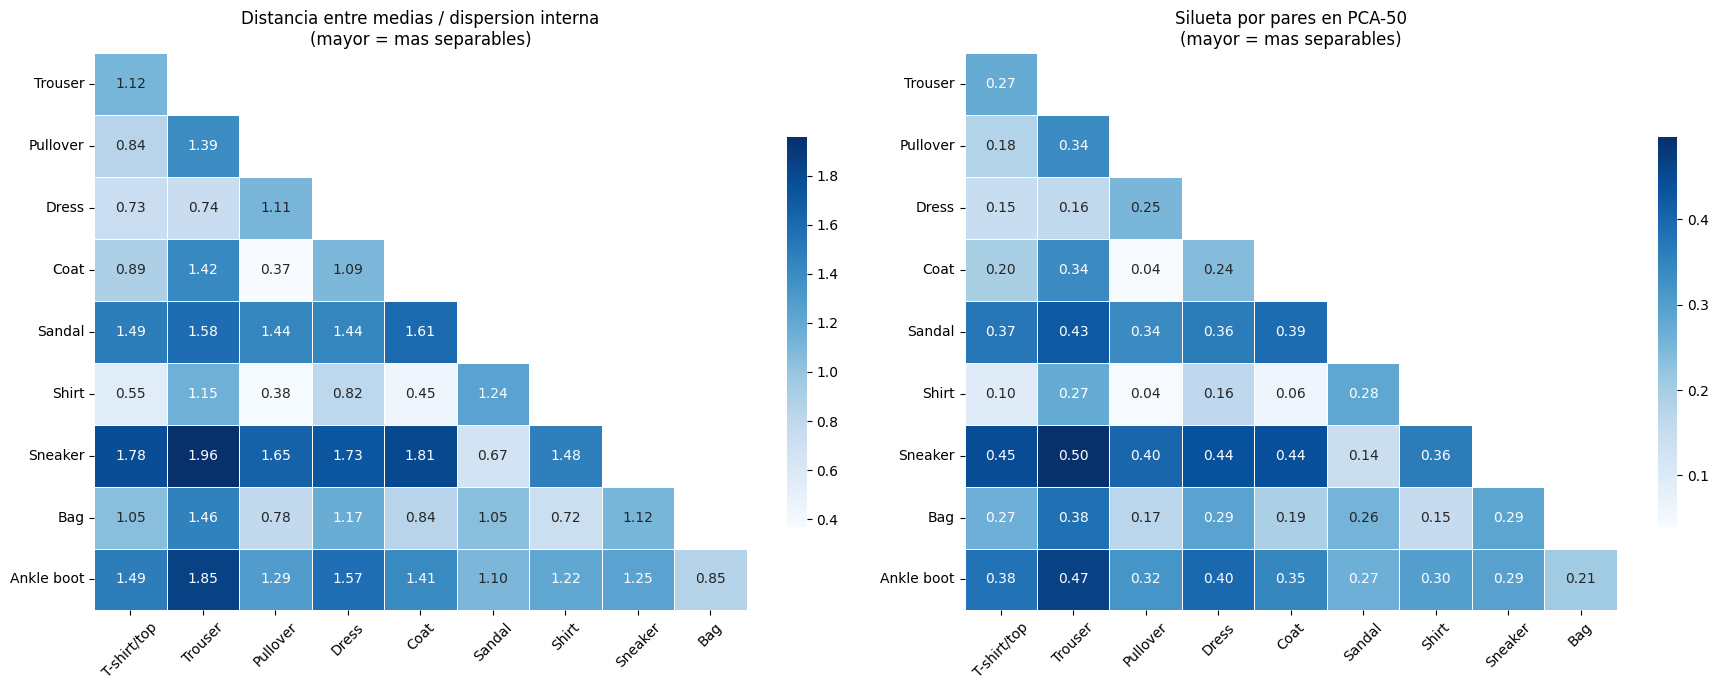

,Dist. normalizada,Silueta
Par,,
Coat vs Pullover,0.37,0.04
Shirt vs Pullover,0.38,0.04
Shirt vs Coat,0.45,0.06
Shirt vs T-shirt/top,0.55,0.10
Sneaker vs Sandal,0.67,0.14
,Dist. normalizada,Silueta
Par,,
Sneaker vs Trouser,1.96,0.50
Ankle boot vs Trouser,1.85,0.47


In [9]:
# Dispersion interna de cada clase: raiz de la varianza total (suma de varianzas de los 784 pixeles)
dispersion_interna = np.array([np.sqrt(eda_X[y_train == c].var(axis=0).sum()) for c in range(10)])
centros = np.stack([eda_X[y_train == c].mean(axis=0) for c in range(10)])

idx_sil = muestra_estratificada(y_train, 500)   # 500 por clase: silhouette es O(n^2) por par
Z_sil, y_sil = Z_train[idx_sil], y_train[idx_sil]

dist_norm = np.zeros((10, 10))
silueta = np.zeros((10, 10))
for i in range(10):
    for j in range(i):
        dist_norm[i, j] = np.linalg.norm(centros[i] - centros[j]) / np.sqrt((dispersion_interna[i] ** 2 + dispersion_interna[j] ** 2) / 2)
        m = np.isin(y_sil, [i, j])
        silueta[i, j] = silhouette_score(Z_sil[m], y_sil[m])

fig, ejes = plt.subplots(1, 2, figsize=(18, 7))
heatmap_triangular(dist_norm, 'Distancia entre medias / dispersion interna\n(mayor = mas separables)', ejes[0], 'Blues')
heatmap_triangular(silueta, 'Silueta por pares en PCA-50\n(mayor = mas separables)', ejes[1], 'Blues')
plt.tight_layout()
plt.show()

filas = []
for i in range(10):
    for j in range(i):
        filas.append({'Par': f'{NOMBRES_CLASES[i]} vs {NOMBRES_CLASES[j]}',
                      'Dist. normalizada': dist_norm[i, j], 'Silueta': silueta[i, j]})
ranking = pd.DataFrame(filas)
ranking['Rango medio'] = (ranking['Dist. normalizada'].rank() + ranking['Silueta'].rank()) / 2
ranking = ranking.sort_values('Rango medio').set_index('Par')
del ranking['Rango medio']

# El indice arma cada par como "clase de id mayor vs clase de id menor"
pares_guia = ranking.loc[['Ankle boot vs Sandal', 'Coat vs Pullover']]
mostrar_lado_a_lado([('5 pares mas DIFICILES', ranking.head(5)),
                     ('5 pares mas FACILES', ranking.tail(5).iloc[::-1]),
                     ('Ejemplos de la consigna', pares_guia)], cmap='Blues', precision=2)

### Conclusiones — Separabilidad entre pares

- ¿Los pares más difíciles coinciden con las confusiones que esperabas mirar las imágenes medias?
- ¿Qué par vas a elegir para el Ejercicio 1.2? ¿Uno fácil, uno difícil, o ambos para comparar el AUC?
- ¿Hay algún par que una medida marque como fácil y la otra como difícil? ¿A qué se puede deber?

<!-- Completar -->

## 8. Estructura no lineal: PCA vs. t-SNE vs. UMAP
**Pregunta:** ¿las clases que PCA solapa se separan con una proyección no lineal? ¿Hay subgrupos dentro de una clase?

**Por qué así:** PCA solo captura estructura lineal. t-SNE y UMAP se aplican sobre los 50 primeros componentes (como reducción de ruido previa y para acelerar) y sobre una muestra estratificada de 5.000 imágenes, porque t-SNE es costoso.

**Advertencias:** en t-SNE las distancias *globales* entre grupos no son interpretables y el resultado depende de `perplexity` (se fija en 30); solo se lee vecindad local. UMAP conserva algo más de estructura global, pero tampoco es una distancia literal. Los tres paneles usan **las mismas** 5.000 imágenes.

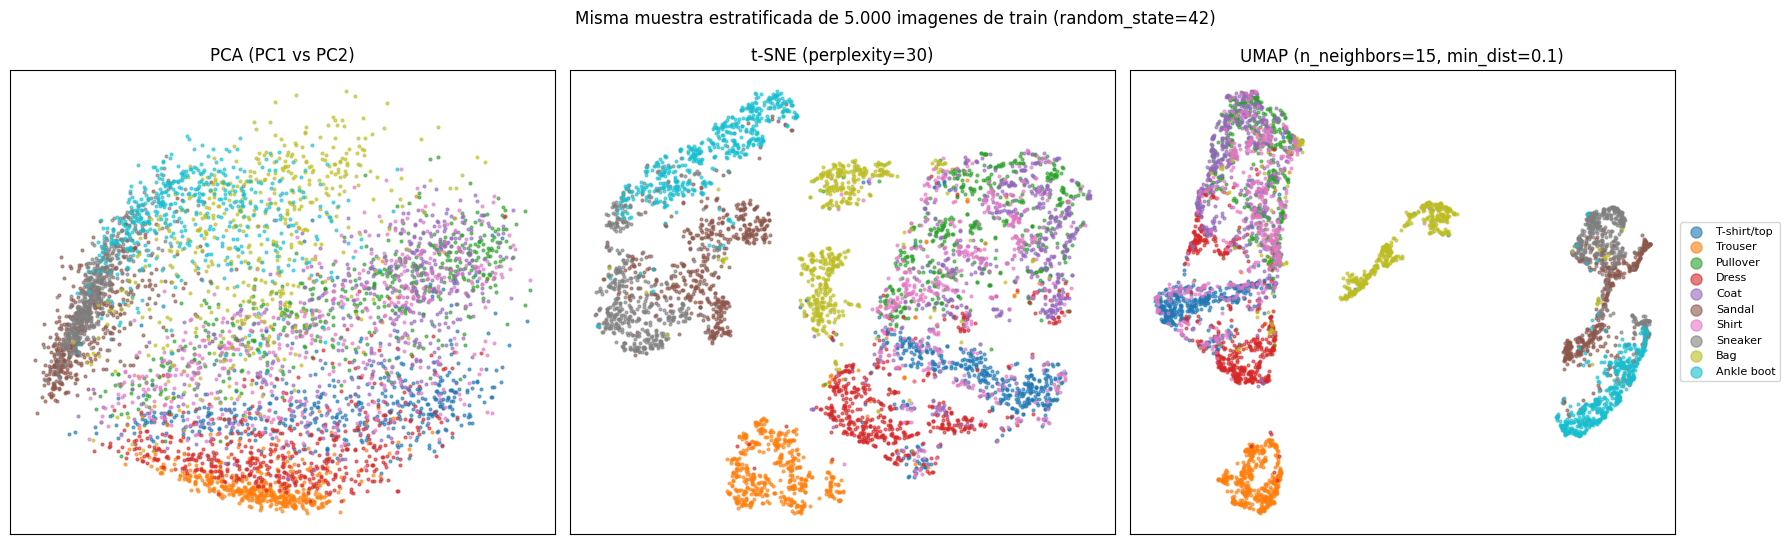

In [10]:
idx_no_lineal = muestra_estratificada(y_train, 500)   # 5.000 imagenes (500 por clase)
Z_entrada = Z_train[idx_no_lineal]
y_m = y_train[idx_no_lineal]

Z_tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEMILLA).fit_transform(Z_entrada)
Z_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=SEMILLA, n_jobs=1).fit_transform(Z_entrada)

fig, ejes = plt.subplots(1, 3, figsize=(18, 5.5))
dispersion_por_clase(Z_entrada[:, :2], y_m, ejes[0], 'PCA (PC1 vs PC2)')
dispersion_por_clase(Z_tsne, y_m, ejes[1], 't-SNE (perplexity=30)')
dispersion_por_clase(Z_umap, y_m, ejes[2], 'UMAP (n_neighbors=15, min_dist=0.1)')
ejes[2].legend(markerscale=4, fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5))
fig.suptitle('Misma muestra estratificada de 5.000 imagenes de train (random_state=42)')
plt.tight_layout()
plt.show()

### Conclusiones — PCA vs. t-SNE vs. UMAP

- ¿Qué clases se separan claramente en t-SNE/UMAP y en PCA quedaban mezcladas?
- ¿Qué clases siguen solapadas incluso en las proyecciones no lineales? ¿Coinciden con el ranking de la sección 7?
- ¿Se ven subgrupos dentro de alguna clase (por ejemplo, Sandal o Bag)?

<!-- Completar -->

## 9. Consistencia entre train y test
**Pregunta:** ¿el conjunto de test viene de la misma distribución que train? Si no, un accuracy bajo en test no sería culpa del modelo ni de sus hiperparámetros.

**Por qué así:** se compara la intensidad media por imagen y por clase (tabla con el estadístico de KS, que mide el tamaño de la diferencia; el p-valor no se usa porque con n = 60.000 vs. 10.000 rechaza diferencias irrelevantes) y las proyecciones PC1/PC2 de ambos conjuntos con el PCA ajustado solo en train.

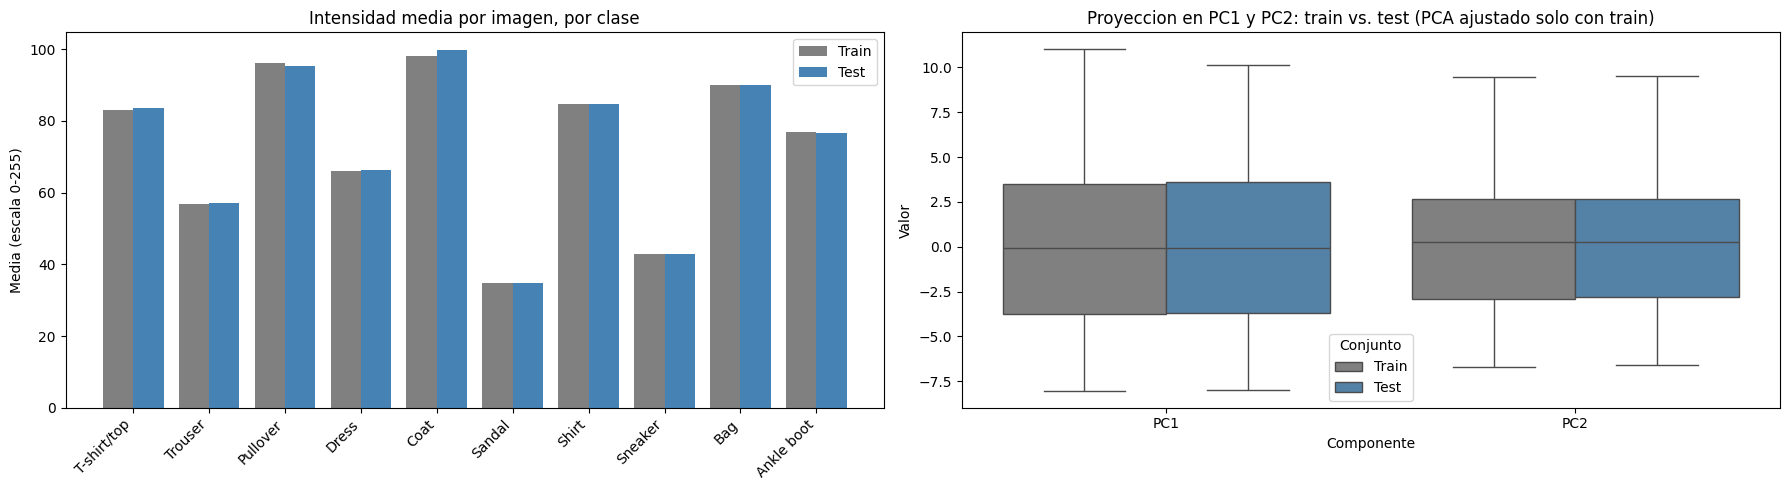

,Media train,Media test,Diferencia,KS (estadistico)
Clase,,,,
T-shirt/top,83.030,83.624,0.594,0.036
Trouser,56.841,56.981,0.141,0.023
Pullover,96.059,95.353,-0.706,0.030
Dress,66.019,66.395,0.376,0.024
Coat,98.258,99.745,1.487,0.037
Sandal,34.868,34.757,-0.110,0.015
Shirt,84.605,84.858,0.253,0.020
Sneaker,42.762,43.020,0.258,0.022
Bag,90.157,90.139,-0.018,0.029


In [11]:
media_test = X_test.reshape(len(X_test), -1).mean(axis=1)
filas = []
for c in range(10):
    a, b = media_por_imagen[y_train == c], media_test[y_test == c]
    filas.append({'Clase': NOMBRES_CLASES[c], 'Media train': a.mean(), 'Media test': b.mean(),
                  'Diferencia': b.mean() - a.mean(), 'KS (estadistico)': stats.ks_2samp(a, b).statistic})
tabla_tt = pd.DataFrame(filas).set_index('Clase')

Z_test = pca.transform(eda_X_test)[:, :2]
pcs = pd.concat([
    pd.DataFrame({'Componente': 'PC1', 'Conjunto': 'Train', 'Valor': Z_train[:, 0]}),
    pd.DataFrame({'Componente': 'PC2', 'Conjunto': 'Train', 'Valor': Z_train[:, 1]}),
    pd.DataFrame({'Componente': 'PC1', 'Conjunto': 'Test', 'Valor': Z_test[:, 0]}),
    pd.DataFrame({'Componente': 'PC2', 'Conjunto': 'Test', 'Valor': Z_test[:, 1]}),
])

fig, ejes = plt.subplots(1, 2, figsize=(18, 5))
ancho = 0.4
x = np.arange(10)
ejes[0].bar(x - ancho / 2, tabla_tt['Media train'], ancho, label='Train', color='gray')
ejes[0].bar(x + ancho / 2, tabla_tt['Media test'], ancho, label='Test', color='steelblue')
ejes[0].set_xticks(x)
ejes[0].set_xticklabels(NOMBRES_CLASES, rotation=45, ha='right')
ejes[0].set_title('Intensidad media por imagen, por clase')
ejes[0].set_ylabel('Media (escala 0-255)')
ejes[0].legend()

sns.boxplot(data=pcs, x='Componente', y='Valor', hue='Conjunto', palette={'Train': 'gray', 'Test': 'steelblue'},
            fliersize=1, ax=ejes[1])
ejes[1].set_title('Proyeccion en PC1 y PC2: train vs. test (PCA ajustado solo con train)')
plt.tight_layout()
plt.show()

mostrar_lado_a_lado([('Train vs. test por clase', tabla_tt)], cmap='Blues', precision=3)

### Conclusiones — Consistencia train/test

- ¿Las diferencias entre train y test son del orden del ruido o hay alguna clase que se aparte?
- ¿Sería razonable comparar el accuracy de validación cruzada (train) con el de test?

<!-- Completar -->

## 10. Insumos para los Ejercicios 2 y 3
**Pregunta:** ¿qué datos medidos arriba condicionan cómo configurar Optuna y el MLP? Es una tabla de datos, no de decisiones: las decisiones son tuyas.

**Por qué así:** consolida en un solo lugar las cifras que ya se calcularon (nada se entrena acá). El costo de Optuna se expresa en *cantidad de ajustes de árbol*, no en tiempo, porque el tiempo depende de la máquina (Colab vs. local) y solo se puede medir entrenando.

In [12]:
N_TRIALS_MIN = 50            # minimo que pide la consigna
FOLDS_ASUMIDOS = 5           # cross_val_score usa 5 folds por defecto en clasificacion
arboles_promedio = (50 + 200) / 2   # punto medio del rango de n_estimators de la consigna
arboles_totales = N_TRIALS_MIN * FOLDS_ASUMIDOS * arboles_promedio
n_fit_cv = int(len(eda_X) * (FOLDS_ASUMIDOS - 1) / FOLDS_ASUMIDOS)

insumos = pd.DataFrame({
    'Dato medido': [
        f'{len(eda_X):,} imagenes de train x 784 pixeles; 10 clases, de {cuentas_train.min():,} a {cuentas_train.max():,} imagenes cada una',
        f'{comp_para[95]} componentes explican 95% de la varianza; {comp_para[99]} explican 99%',
        f'{int((desvio_global <= 5).sum())} pixeles con desvio menor o igual a 5 (de 255); {int((plano_train.std(axis=0) == 0).sum())} con varianza cero',
        f'{conteo_valores[0] / conteo_valores.sum():.1%} de los pixeles vale 0; el resto va de 1 a 255',
        f'{N_TRIALS_MIN} trials x {FOLDS_ASUMIDOS} folds x ~{arboles_promedio:.0f} arboles = ~{arboles_totales:,.0f} arboles, cada uno sobre ~{n_fit_cv:,} imagenes',
        f'Clase con menos imagenes: {cuentas_train.min():,}; azar = {1 / 10:.0%}',
        f'Diferencia maxima train-test en intensidad media por clase: {tabla_tt["Diferencia"].abs().max():.2f} (de 255)',
    ],
    'Ejercicio que informa': [
        'Ej. 2 (costo por trial); Ej. 3 (tiempo por epoca)',
        'Ej. 1 y 2 (max_depth, cantidad efectiva de features)',
        'Ej. 1 y 2 (features irrelevantes para RF)',
        'Ej. 3 (escala de entrada del MLP)',
        'Ej. 2 (presupuesto de Optuna)',
        'Ej. 2 y 3 (accuracy como objetivo)',
        'Ej. 1, 2 y 3 (validez de comparar train vs. test)',
    ],
})
mostrar_tabla_texto(insumos)

Dato medido,Ejercicio que informa
"60,000 imagenes de train x 784 pixeles; 10 clases, de 6,000 a 6,000 imagenes cada una",Ej. 2 (costo por trial); Ej. 3 (tiempo por epoca)
188 componentes explican 95% de la varianza; 459 explican 99%,"Ej. 1 y 2 (max_depth, cantidad efectiva de features)"
20 pixeles con desvio menor o igual a 5 (de 255); 0 con varianza cero,Ej. 1 y 2 (features irrelevantes para RF)
50.2% de los pixeles vale 0; el resto va de 1 a 255,Ej. 3 (escala de entrada del MLP)
"50 trials x 5 folds x ~125 arboles = ~31,250 arboles, cada uno sobre ~48,000 imagenes",Ej. 2 (presupuesto de Optuna)
"Clase con menos imagenes: 6,000; azar = 10%",Ej. 2 y 3 (accuracy como objetivo)
Diferencia maxima train-test en intensidad media por clase: 1.49 (de 255),"Ej. 1, 2 y 3 (validez de comparar train vs. test)"


### Conclusiones — Insumos para los Ejercicios 2 y 3

- ¿El costo estimado de 50 trials sobre las 60.000 imágenes es razonable en tu entorno? ¿Necesitás una submuestra para Optuna?
- ¿Qué escala de entrada necesita el MLPClassifier y qué debería hacerse (y dónde) para no filtrar información de test?
- ¿Qué par del ranking (sección 7) vas a usar en el Ejercicio 1.2?

<!-- Completar -->